# Evaluasi Model: YOLOv8s vs RetinaNet
Notebook ini mencakup:
1. **Confusion Matrix** — untuk data test dan validasi
2. **Intersection over Union (IoU)** — ketepatan bounding box vs ground truth pakar
3. **Perbandingan Hyperparameter** — YOLOv8s vs RetinaNet

In [2]:
# ── Cell 1: Import & Konfigurasi ────────────────────────────────────────────
import os
import torch
import torchvision
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Path konfigurasi ────────────────────────────────────────────────────────
YOLO_WEIGHT_PATH   = 'runs/yolov8s_kardio/weights/best.pt'
RETINA_WEIGHT_PATH = 'outputs/retinanet_kardio_best.pt'

TEST_IMG_DIR   = Path('dataset/test/images')
TEST_LBL_DIR   = Path('dataset/test/labels')
VALID_IMG_DIR  = Path('dataset/valid/images')
VALID_LBL_DIR  = Path('dataset/valid/labels')

CLASS_NAMES    = ['kardiomegali', 'normal']   # index 0 = kardiomegali, 1 = normal
YOLO_CONF      = 0.25
YOLO_IOU       = 0.45
RETINA_CONF    = 0.30
IOU_THRESHOLD  = 0.5   # threshold IoU untuk dianggap deteksi benar

print('Konfigurasi siap.')

Device: cpu
Konfigurasi siap.


In [3]:
# ── Cell 2: Load Model ───────────────────────────────────────────────────────
# Load YOLOv8s
yolo_model = YOLO(YOLO_WEIGHT_PATH)
print(f'✅ YOLOv8s loaded')

# Load RetinaNet
def load_retinanet(path):
    checkpoint = torch.load(path, map_location=DEVICE)
    if isinstance(checkpoint, dict) and 'model' in checkpoint and not any(
        k.startswith(('backbone', 'head')) for k in checkpoint.keys()
    ):
        state_dict = checkpoint['model']
    elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    key = 'head.classification_head.cls_logits.weight'
    num_classes = state_dict[key].shape[0] // 9 if key in state_dict else 91
    print(f'   Jumlah class: {num_classes} (termasuk background)')

    for variant in ['retinanet_resnet50_fpn', 'retinanet_resnet50_fpn_v2']:
        try:
            if variant == 'retinanet_resnet50_fpn_v2':
                model = torchvision.models.detection.retinanet_resnet50_fpn_v2(
                    weights=None, weights_backbone=None, num_classes=num_classes)
            else:
                model = torchvision.models.detection.retinanet_resnet50_fpn(
                    weights=None, weights_backbone=None, num_classes=num_classes)
            model.load_state_dict(state_dict)
            model.to(DEVICE)
            model.eval()
            print(f'   Arsitektur: {variant}')
            return model
        except RuntimeError:
            continue
    raise RuntimeError('Gagal load RetinaNet')

retina_model = load_retinanet(RETINA_WEIGHT_PATH)
print(f'✅ RetinaNet loaded')

✅ YOLOv8s loaded
   Jumlah class: 3 (termasuk background)
   Arsitektur: retinanet_resnet50_fpn
✅ RetinaNet loaded


In [4]:
# ── Cell 3: Helper Functions ─────────────────────────────────────────────────

def read_yolo_label(label_path, img_w, img_h):
    """Baca file label YOLO dan konversi ke format [class_id, x1, y1, x2, y2]."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            x2 = (cx + w/2) * img_w
            y2 = (cy + h/2) * img_h
            boxes.append([cls_id, x1, y1, x2, y2])
    return boxes


def compute_iou(box1, box2):
    """Hitung IoU antara dua bounding box [x1, y1, x2, y2]."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def predict_yolo_boxes(model, img_path, conf=0.25, iou=0.45):
    """Prediksi YOLO, return list [class_id, x1, y1, x2, y2, score]."""
    results = model.predict(source=str(img_path), conf=conf, iou=iou, verbose=False)
    r = results[0]
    preds = []
    for b in r.boxes:
        cls_id = int(b.cls[0])
        score  = float(b.conf[0])
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        preds.append([cls_id, x1, y1, x2, y2, score])
    return preds


def predict_retina_boxes(model, img_path, conf=0.5):
    """Prediksi RetinaNet, return list [class_id, x1, y1, x2, y2, score].
    Catatan: RetinaNet torchvision class index 1=kardiomegali, 2=normal (0=background)."""
    image = Image.open(img_path).convert('RGB')
    img_tensor = TF.to_tensor(image).to(DEVICE)
    with torch.no_grad():
        preds = model([img_tensor])[0]
    boxes  = preds['boxes'].cpu().numpy()
    labels = preds['labels'].cpu().numpy()
    scores = preds['scores'].cpu().numpy()
    result = []
    for box, label, score in zip(boxes, labels, scores):
        if score < conf:
            continue
        # Konversi: RetinaNet label 1->0 (kardiomegali), 2->1 (normal)
        cls_id = int(label) - 1
        if cls_id < 0:
            continue
        x1, y1, x2, y2 = [float(v) for v in box]
        result.append([cls_id, x1, y1, x2, y2, float(score)])
    return result


def evaluate_dataset(yolo_model, retina_model, img_dir, lbl_dir,
                     class_names, yolo_conf, yolo_iou, retina_conf, iou_thresh):
    """
    Evaluasi kedua model pada satu dataset.
    Return: dict berisi gt_classes, yolo_preds, retina_preds, yolo_ious, retina_ious
    """
    img_paths = sorted([
        p for p in Path(img_dir).iterdir()
        if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')
    ])

    gt_classes     = []   # ground truth class per gambar
    yolo_preds_cls = []   # prediksi class YOLO per gambar
    retina_preds_cls = [] # prediksi class RetinaNet per gambar
    yolo_ious      = []   # IoU per deteksi YOLO
    retina_ious    = []   # IoU per deteksi RetinaNet

    print(f'Evaluasi {len(img_paths)} gambar...')
    for i, img_path in enumerate(img_paths):
        if (i+1) % 10 == 0:
            print(f'  {i+1}/{len(img_paths)}')

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        lbl_path = Path(lbl_dir) / (img_path.stem + '.txt')
        gt_boxes = read_yolo_label(str(lbl_path), img_w, img_h)

        if not gt_boxes:
            continue

        gt_cls = gt_boxes[0][0]  # ambil class pertama sebagai label gambar
        gt_classes.append(gt_cls)

        # ── YOLO ──
        yolo_preds = predict_yolo_boxes(yolo_model, img_path, yolo_conf, yolo_iou)
        if yolo_preds:
            best = max(yolo_preds, key=lambda x: x[5])  # ambil confidence tertinggi
            yolo_preds_cls.append(best[0])
            best_iou = max(
                compute_iou(best[1:5], gt[1:5]) for gt in gt_boxes
            )
            yolo_ious.append(best_iou)
        else:
            # tidak ada deteksi — prediksi kelas lain dari ground truth
            yolo_preds_cls.append(1 - gt_cls)
            yolo_ious.append(0.0)

        # ── RetinaNet ──
        retina_preds = predict_retina_boxes(retina_model, img_path, retina_conf)
        if retina_preds:
            best_r = max(retina_preds, key=lambda x: x[5])
            retina_preds_cls.append(best_r[0])
            best_iou_r = max(
                compute_iou(best_r[1:5], gt[1:5]) for gt in gt_boxes
            )
            retina_ious.append(best_iou_r)
        else:
            retina_preds_cls.append(1 - gt_cls)
            retina_ious.append(0.0)

    return {
        'gt'          : gt_classes,
        'yolo_preds'  : yolo_preds_cls,
        'retina_preds': retina_preds_cls,
        'yolo_ious'   : yolo_ious,
        'retina_ious' : retina_ious,
    }

print('Helper functions siap.')

Helper functions siap.


In [5]:
# ── Cell 4: Evaluasi Data TEST ───────────────────────────────────────────────
print('='*55)
print('EVALUASI DATA TEST')
print('='*55)
test_results = evaluate_dataset(
    yolo_model, retina_model,
    TEST_IMG_DIR, TEST_LBL_DIR,
    CLASS_NAMES, YOLO_CONF, YOLO_IOU, RETINA_CONF, IOU_THRESHOLD
)
print(f'\nSelesai. Total gambar dievaluasi: {len(test_results["gt"])}')

EVALUASI DATA TEST
Evaluasi 94 gambar...
  10/94
  20/94
  30/94
  40/94
  50/94
  60/94
  70/94
  80/94
  90/94

Selesai. Total gambar dievaluasi: 94


In [6]:
# ── Cell 5: Evaluasi Data VALID ──────────────────────────────────────────────
print('='*55)
print('EVALUASI DATA VALIDASI')
print('='*55)
valid_results = evaluate_dataset(
    yolo_model, retina_model,
    VALID_IMG_DIR, VALID_LBL_DIR,
    CLASS_NAMES, YOLO_CONF, YOLO_IOU, RETINA_CONF, IOU_THRESHOLD
)
print(f'\nSelesai. Total gambar dievaluasi: {len(valid_results["gt"])}')

EVALUASI DATA VALIDASI
Evaluasi 94 gambar...
  10/94
  20/94
  30/94
  40/94
  50/94
  60/94
  70/94
  80/94
  90/94

Selesai. Total gambar dievaluasi: 94


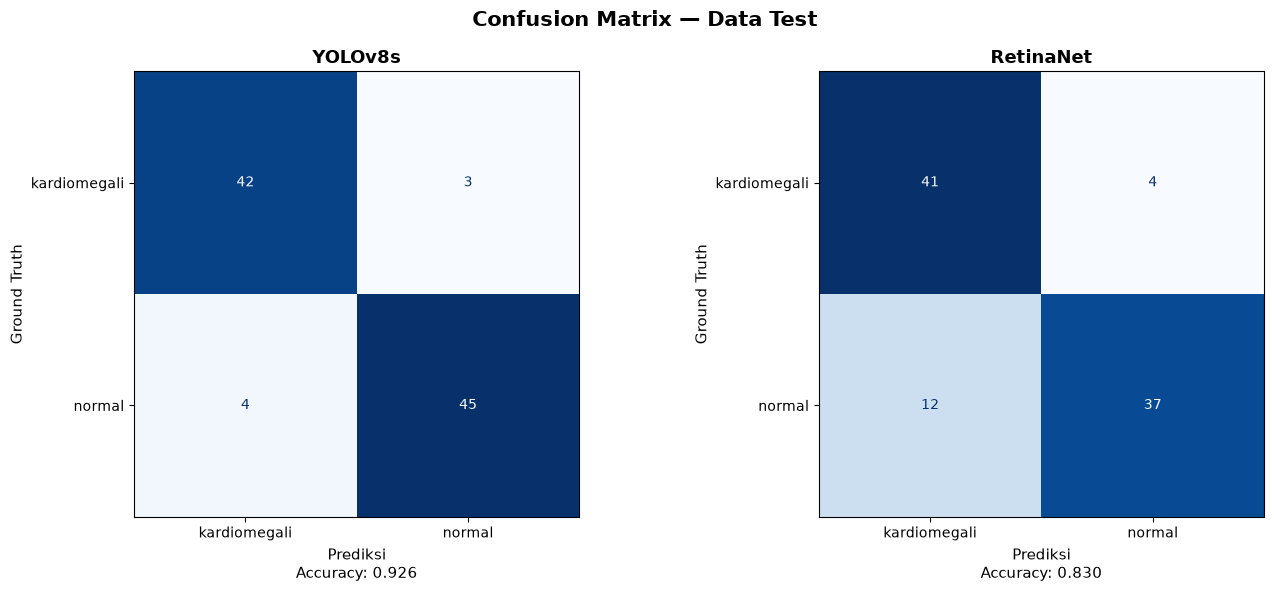

Gambar disimpan: confusion_matrix_data_test.png


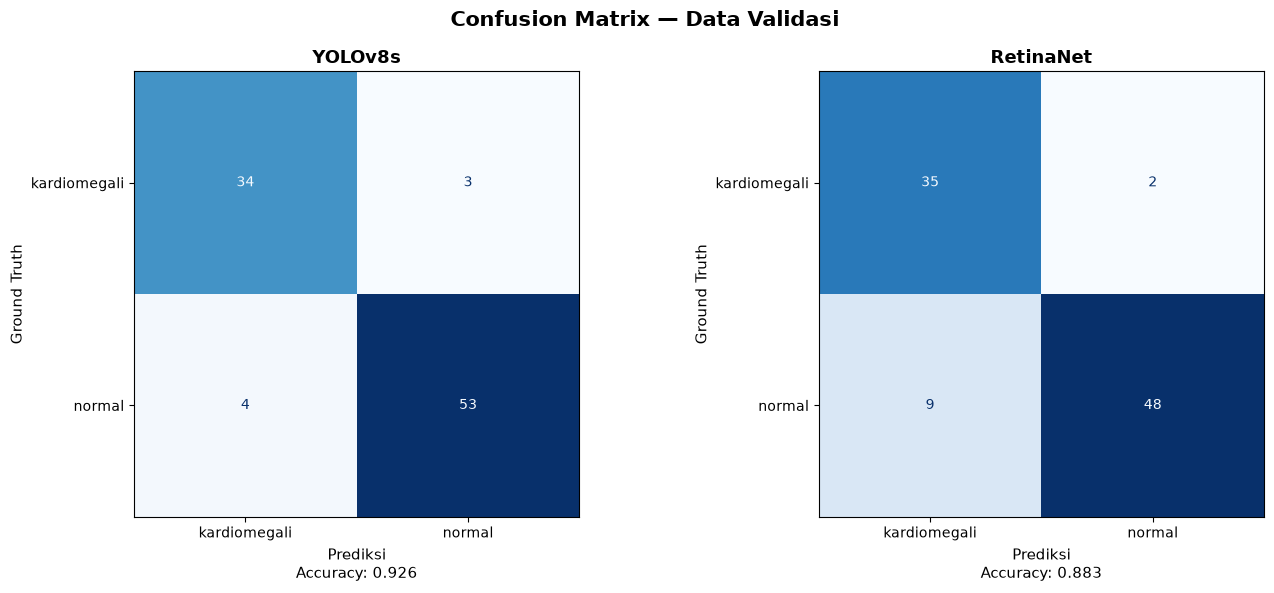

Gambar disimpan: confusion_matrix_data_validasi.png


In [7]:
# ── Cell 6: Confusion Matrix ─────────────────────────────────────────────────
def plot_confusion_matrices(results, dataset_name, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Confusion Matrix — {dataset_name}', fontsize=15, fontweight='bold')

    for ax, preds, model_name in zip(
        axes,
        [results['yolo_preds'], results['retina_preds']],
        ['YOLOv8s', 'RetinaNet']
    ):
        cm = confusion_matrix(results['gt'], preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(model_name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Prediksi', fontsize=11)
        ax.set_ylabel('Ground Truth', fontsize=11)

        # Tambahkan metrik
        report = classification_report(results['gt'], preds,
                                       target_names=class_names, output_dict=True)
        acc = report['accuracy']
        ax.set_xlabel(f'Prediksi\nAccuracy: {acc:.3f}', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{dataset_name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gambar disimpan: confusion_matrix_{dataset_name.lower().replace(" ", "_")}.png')


# Plot confusion matrix untuk test dan valid
plot_confusion_matrices(test_results,  'Data Test',     CLASS_NAMES)
plot_confusion_matrices(valid_results, 'Data Validasi', CLASS_NAMES)

In [8]:
# ── Cell 7: Classification Report (Precision, Recall, F1) ────────────────────
def print_classification_report(results, dataset_name, class_names):
    print(f'\n{"="*55}')
    print(f'CLASSIFICATION REPORT — {dataset_name}')
    print(f'{"="*55}')
    for preds, model_name in zip(
        [results['yolo_preds'], results['retina_preds']],
        ['YOLOv8s', 'RetinaNet']
    ):
        print(f'\n── {model_name} ──')
        print(classification_report(results['gt'], preds, target_names=class_names))

print_classification_report(test_results,  'Data Test',     CLASS_NAMES)
print_classification_report(valid_results, 'Data Validasi', CLASS_NAMES)


CLASSIFICATION REPORT — Data Test

── YOLOv8s ──
              precision    recall  f1-score   support

kardiomegali       0.91      0.93      0.92        45
      normal       0.94      0.92      0.93        49

    accuracy                           0.93        94
   macro avg       0.93      0.93      0.93        94
weighted avg       0.93      0.93      0.93        94


── RetinaNet ──
              precision    recall  f1-score   support

kardiomegali       0.77      0.91      0.84        45
      normal       0.90      0.76      0.82        49

    accuracy                           0.83        94
   macro avg       0.84      0.83      0.83        94
weighted avg       0.84      0.83      0.83        94


CLASSIFICATION REPORT — Data Validasi

── YOLOv8s ──
              precision    recall  f1-score   support

kardiomegali       0.89      0.92      0.91        37
      normal       0.95      0.93      0.94        57

    accuracy                           0.93        94
   macr

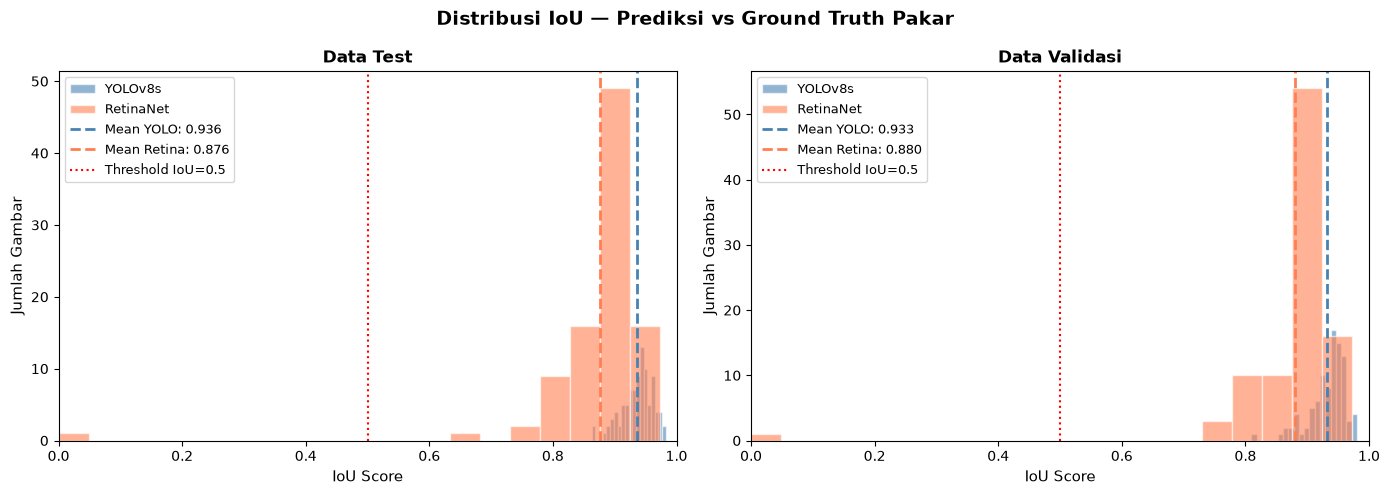

Gambar disimpan: iou_distribution.png

RINGKASAN IoU — Data Test

── YOLOv8s ──
  Mean IoU   : 0.9365
  Median IoU : 0.9401
  Min IoU    : 0.8626
  Max IoU    : 0.9829
  IoU ≥ 0.5 : 94/94 gambar (100.0%)

── RetinaNet ──
  Mean IoU   : 0.8759
  Median IoU : 0.8917
  Min IoU    : 0.0000
  Max IoU    : 0.9741
  IoU ≥ 0.5 : 93/94 gambar (98.9%)

RINGKASAN IoU — Data Validasi

── YOLOv8s ──
  Mean IoU   : 0.9325
  Median IoU : 0.9420
  Min IoU    : 0.8097
  Max IoU    : 0.9805
  IoU ≥ 0.5 : 94/94 gambar (100.0%)

── RetinaNet ──
  Mean IoU   : 0.8805
  Median IoU : 0.9010
  Min IoU    : 0.0000
  Max IoU    : 0.9727
  IoU ≥ 0.5 : 93/94 gambar (98.9%)


In [11]:
# ── Cell 8: Intersection over Union (IoU) ────────────────────────────────────
def plot_iou_comparison(test_res, valid_res):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribusi IoU — Prediksi vs Ground Truth Pakar', fontsize=14, fontweight='bold')

    for ax, res, title in zip(axes, [test_res, valid_res], ['Data Test', 'Data Validasi']):
        yolo_ious   = res['yolo_ious']
        retina_ious = res['retina_ious']

        ax.hist(yolo_ious,   bins=20, alpha=0.6, label='YOLOv8s',   color='steelblue', edgecolor='white')
        ax.hist(retina_ious, bins=20, alpha=0.6, label='RetinaNet', color='coral',     edgecolor='white')
        ax.axvline(np.mean(yolo_ious),   color='steelblue', linestyle='--', linewidth=2,
                   label=f'Mean YOLO: {np.mean(yolo_ious):.3f}')
        ax.axvline(np.mean(retina_ious), color='coral',     linestyle='--', linewidth=2,
                   label=f'Mean Retina: {np.mean(retina_ious):.3f}')
        ax.axvline(0.5, color='red', linestyle=':', linewidth=1.5, label='Threshold IoU=0.5')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('IoU Score', fontsize=11)
        ax.set_ylabel('Jumlah Gambar', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig('iou_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gambar disimpan: iou_distribution.png')


def print_iou_summary(results, dataset_name, iou_thresh=0.5):
    print(f'\n{"="*55}')
    print(f'RINGKASAN IoU — {dataset_name}')
    print(f'{"="*55}')
    for ious, model_name in zip(
        [results['yolo_ious'], results['retina_ious']],
        ['YOLOv8s', 'RetinaNet']
    ):
        above = sum(1 for v in ious if v >= iou_thresh)
        print(f'\n── {model_name} ──')
        print(f'  Mean IoU   : {np.mean(ious):.4f}')
        print(f'  Median IoU : {np.median(ious):.4f}')
        print(f'  Min IoU    : {np.min(ious):.4f}')
        print(f'  Max IoU    : {np.max(ious):.4f}')
        print(f'  IoU ≥ {iou_thresh} : {above}/{len(ious)} gambar ({above/len(ious)*100:.1f}%)')


plot_iou_comparison(test_results, valid_results)
print_iou_summary(test_results,  'Data Test')
print_iou_summary(valid_results, 'Data Validasi')

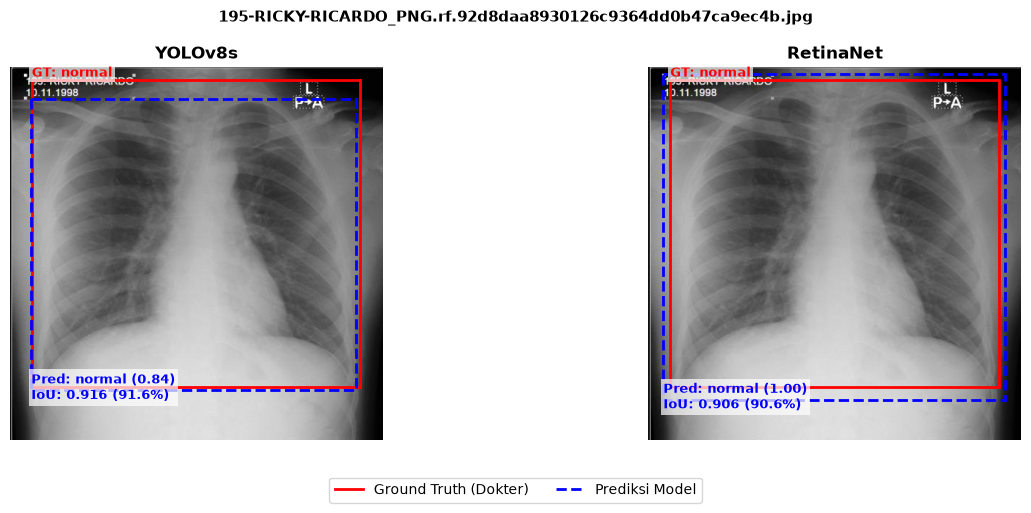

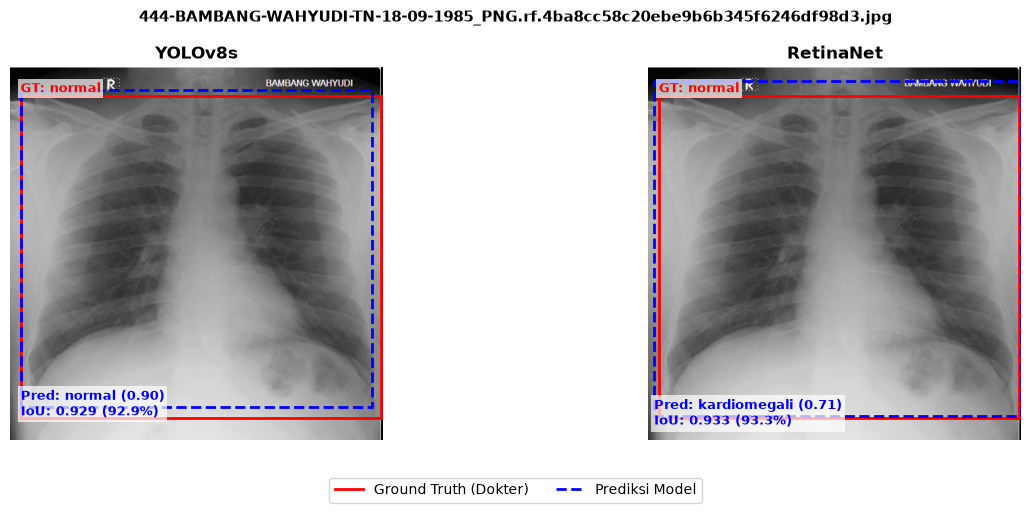

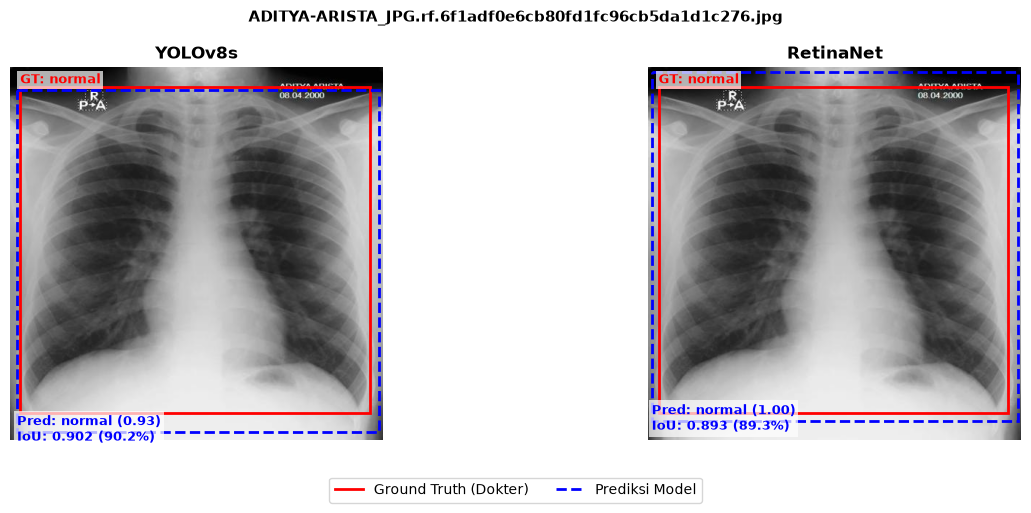

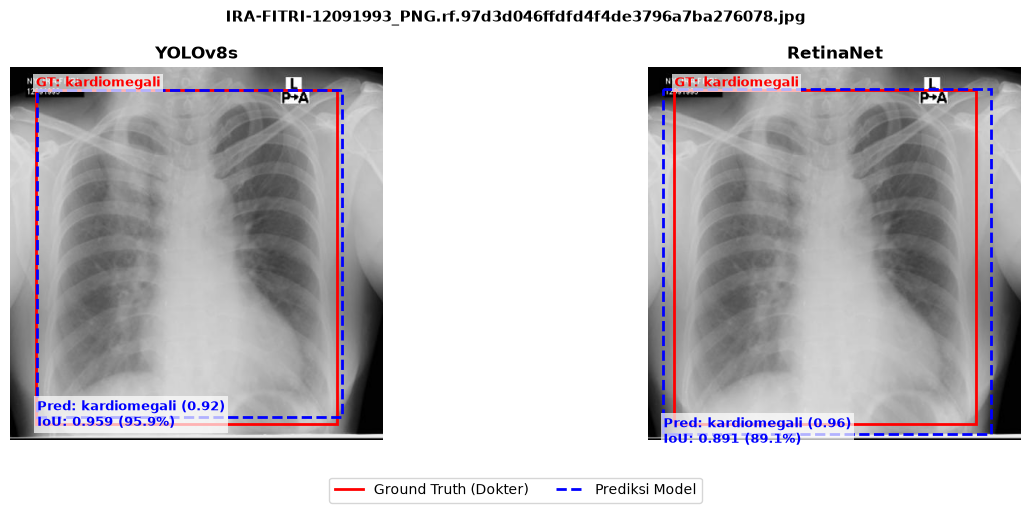

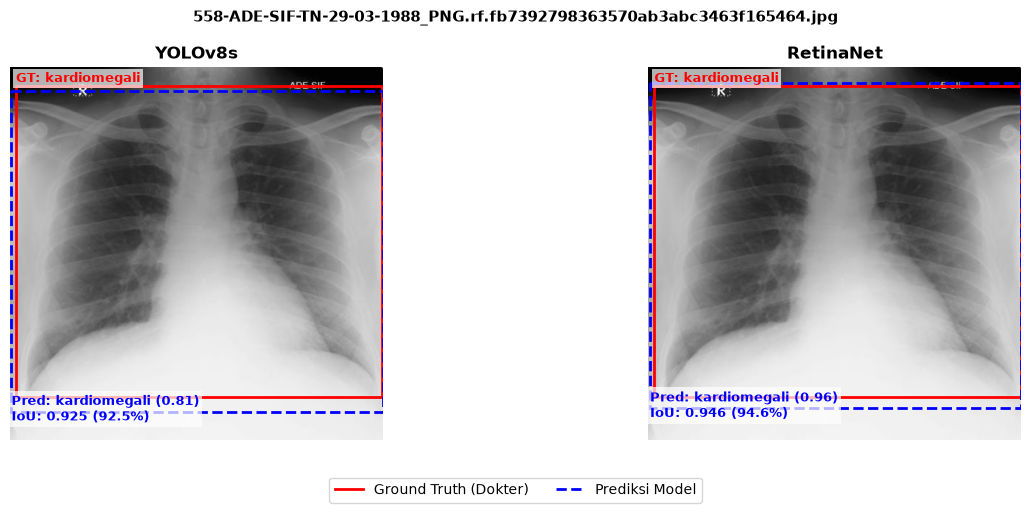

In [12]:
# ── Cell 8b: Visualisasi Ground Truth vs Prediksi (IoU per gambar) ───────────
import random
from matplotlib.lines import Line2D

def visualize_gt_vs_pred(yolo_model, retina_model, img_dir, lbl_dir,
                          class_names, n=5, yolo_conf=0.25, yolo_iou=0.45, retina_conf=0.5):
    img_paths = sorted([
        p for p in Path(img_dir).iterdir()
        if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')
    ])
    random.shuffle(img_paths)
    img_paths = img_paths[:n]

    for img_path in img_paths:
        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        lbl_path = Path(lbl_dir) / (img_path.stem + '.txt')
        gt_boxes = read_yolo_label(str(lbl_path), img_w, img_h)
        if not gt_boxes:
            continue

        yolo_preds   = predict_yolo_boxes(yolo_model, img_path, yolo_conf, yolo_iou)
        retina_preds = predict_retina_boxes(retina_model, img_path, retina_conf)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(img_path.name, fontsize=11, fontweight='bold')

        for ax, preds, model_name in zip(axes, [yolo_preds, retina_preds], ['YOLOv8s', 'RetinaNet']):
            ax.imshow(img)
            ax.set_title(model_name, fontsize=12, fontweight='bold')
            ax.axis('off')

# Gambar ground truth (merah)
            for gt in gt_boxes:
                cls_id, x1, y1, x2, y2 = gt
                cls_name = class_names[cls_id]
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, f'GT: {cls_name}', color='red', fontsize=9, fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

            # Gambar prediksi (biru)
            if preds:
                best = max(preds, key=lambda x: x[5])
                cls_id, x1, y1, x2, y2, score = best
                cls_name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
                best_iou = max(compute_iou([x1,y1,x2,y2], gt[1:5]) for gt in gt_boxes)
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
                ax.add_patch(rect)
                ax.text(x1, y2+12, f'Pred: {cls_name} ({score:.2f})\nIoU: {best_iou:.3f} ({best_iou*100:.1f}%)',
                        color='blue', fontsize=9, fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
            else:
                ax.text(img_w//2, img_h//2, 'Tidak terdeteksi', color='blue',
                        fontsize=12, ha='center', va='center',
                        bbox=dict(facecolor='white', alpha=0.7))

        legend_elements = [
            Line2D([0], [0], color='red',  linewidth=2, label='Ground Truth (Dokter)'),
            Line2D([0], [0], color='blue', linewidth=2, linestyle='--', label='Prediksi Model'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
                   bbox_to_anchor=(0.5, -0.02), frameon=True)
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.12)
        plt.savefig(f'gt_vs_pred_{img_path.stem[:20]}.png', dpi=120, bbox_inches='tight')
        plt.show()


visualize_gt_vs_pred(
    yolo_model, retina_model,
    TEST_IMG_DIR, TEST_LBL_DIR,
    CLASS_NAMES, n=5,
    yolo_conf=YOLO_CONF, yolo_iou=YOLO_IOU, retina_conf=RETINA_CONF
)

In [13]:
# ── Cell 9: Tabel Ringkasan Metrik ───────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def build_summary_table(test_res, valid_res, class_names):
    rows = []
    for dataset_name, res in [('Test', test_res), ('Validasi', valid_res)]:
        for preds, model_name, ious in [
            (res['yolo_preds'],   'YOLOv8s',   res['yolo_ious']),
            (res['retina_preds'], 'RetinaNet', res['retina_ious']),
        ]:
            gt = res['gt']
            rows.append({
                'Dataset'   : dataset_name,
                'Model'     : model_name,
                'Accuracy'  : round(accuracy_score(gt, preds), 4),
                'Precision' : round(precision_score(gt, preds, average='weighted', zero_division=0), 4),
                'Recall'    : round(recall_score(gt, preds, average='weighted', zero_division=0), 4),
                'F1-Score'  : round(f1_score(gt, preds, average='weighted', zero_division=0), 4),
                'Mean IoU'  : round(float(np.mean(ious)), 4),
            })

    df = pd.DataFrame(rows)
    return df

summary_df = build_summary_table(test_results, valid_results, CLASS_NAMES)
print('\n📊 TABEL RINGKASAN METRIK:')
print(summary_df.to_string(index=False))
summary_df.to_csv('ringkasan_metrik.csv', index=False)
print('\nTabel disimpan: ringkasan_metrik.csv')


📊 TABEL RINGKASAN METRIK:
 Dataset     Model  Accuracy  Precision  Recall  F1-Score  Mean IoU
    Test   YOLOv8s    0.9255     0.9258  0.9255    0.9256    0.9365
    Test RetinaNet    0.8298     0.8408  0.8298    0.8292    0.8759
Validasi   YOLOv8s    0.9255     0.9261  0.9255    0.9257    0.9325
Validasi RetinaNet    0.8830     0.8952  0.8830    0.8842    0.8805

Tabel disimpan: ringkasan_metrik.csv


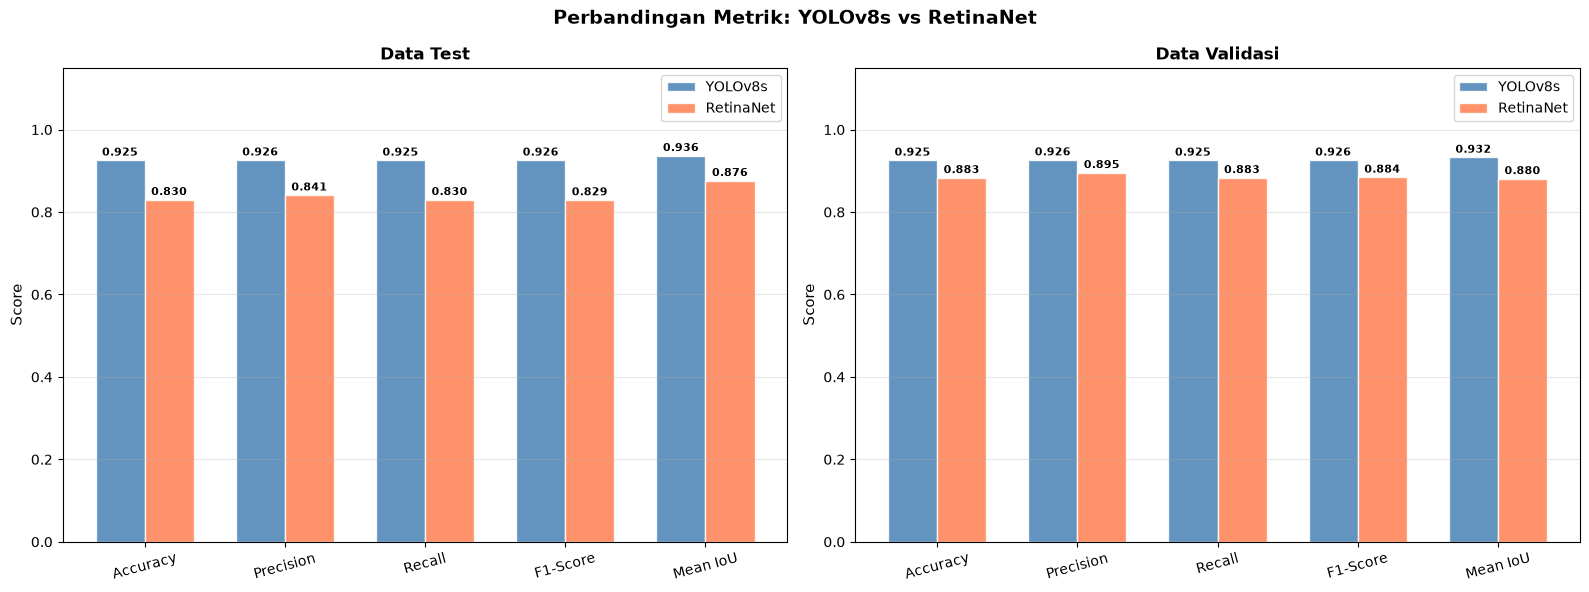

Gambar disimpan: perbandingan_metrik.png


In [14]:
# ── Cell 10: Visualisasi Perbandingan Metrik ─────────────────────────────────
def plot_metrics_comparison(summary_df):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Mean IoU']
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Perbandingan Metrik: YOLOv8s vs RetinaNet', fontsize=14, fontweight='bold')

    colors = {'YOLOv8s': 'steelblue', 'RetinaNet': 'coral'}

    for ax, dataset in zip(axes, ['Test', 'Validasi']):
        df_sub = summary_df[summary_df['Dataset'] == dataset]
        x = np.arange(len(metrics))
        width = 0.35

        for i, (_, row) in enumerate(df_sub.iterrows()):
            vals = [row[m] for m in metrics]
            bars = ax.bar(x + (i - 0.5) * width, vals, width,
                          label=row['Model'], color=colors[row['Model']], alpha=0.85, edgecolor='white')
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

        ax.set_title(f'Data {dataset}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, rotation=15)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel('Score', fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('perbandingan_metrik.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gambar disimpan: perbandingan_metrik.png')

plot_metrics_comparison(summary_df)

In [15]:
# ── Cell 11: Perbandingan Hyperparameter ─────────────────────────────────────
hyperparams = {
    'Hyperparameter'           : [
        'Arsitektur',
        'Backbone',
        'Pretrained',
        'Epochs',
        'Early Stopping Patience',
        'Batch Size',
        'Image Size',
        'Optimizer',
        'Learning Rate (awal)',
        'Learning Rate (akhir / backbone)',
        'Weight Decay',
        'Momentum',
        'LR Scheduler',
        'Warmup Epochs',
        'Freeze Backbone',
        'Augmentasi',
        'Input Normalisasi',
        'Jumlah Class',
    ],
    'YOLOv8s'                  : [
        'YOLOv8s (ultralytics)',
        'CSPDarknet + C2f',
        'Ya (ImageNet)',
        '50',
        '10',
        '16',
        '512 × 512',
        'AdamW',
        '0.001',
        '0.0001',
        '0.0005',
        '0.937',
        'Cosine LR Decay',
        '3',
        'Tidak',
        'Mosaic, Flip, HSV, Translate, Scale',
        'Auto (ultralytics)',
        '2 (kardiomegali, normal)',
    ],
    'RetinaNet'                : [
        'RetinaNet ResNet50 FPN',
        'ResNet50 + FPN',
        'Ya (ImageNet)',
        '50',
        '10',
        '4',
        '512 × 512',
        'AdamW',
        '1e-4 (head)',
        '1e-5 (backbone)',
        '1e-4',
        '— (AdamW)',
        'ReduceLROnPlateau (patience=3, factor=0.5)',
        '— ',
        'Ya (3 epoch pertama)',
        'Standard torchvision transforms',
        'ImageNet mean/std',
        '3 (background, kardiomegali, normal)',
    ],
}

hp_df = pd.DataFrame(hyperparams)

# Tampilkan sebagai tabel
print('\n📋 PERBANDINGAN HYPERPARAMETER')
print(hp_df.to_string(index=False))

# Simpan ke CSV
hp_df.to_csv('perbandingan_hyperparameter.csv', index=False)
print('\nTabel disimpan: perbandingan_hyperparameter.csv')


📋 PERBANDINGAN HYPERPARAMETER
                  Hyperparameter                             YOLOv8s                                  RetinaNet
                      Arsitektur               YOLOv8s (ultralytics)                     RetinaNet ResNet50 FPN
                        Backbone                    CSPDarknet + C2f                             ResNet50 + FPN
                      Pretrained                       Ya (ImageNet)                              Ya (ImageNet)
                          Epochs                                  50                                         50
         Early Stopping Patience                                  10                                         10
                      Batch Size                                  16                                          4
                      Image Size                           512 × 512                                  512 × 512
                       Optimizer                               AdamW     

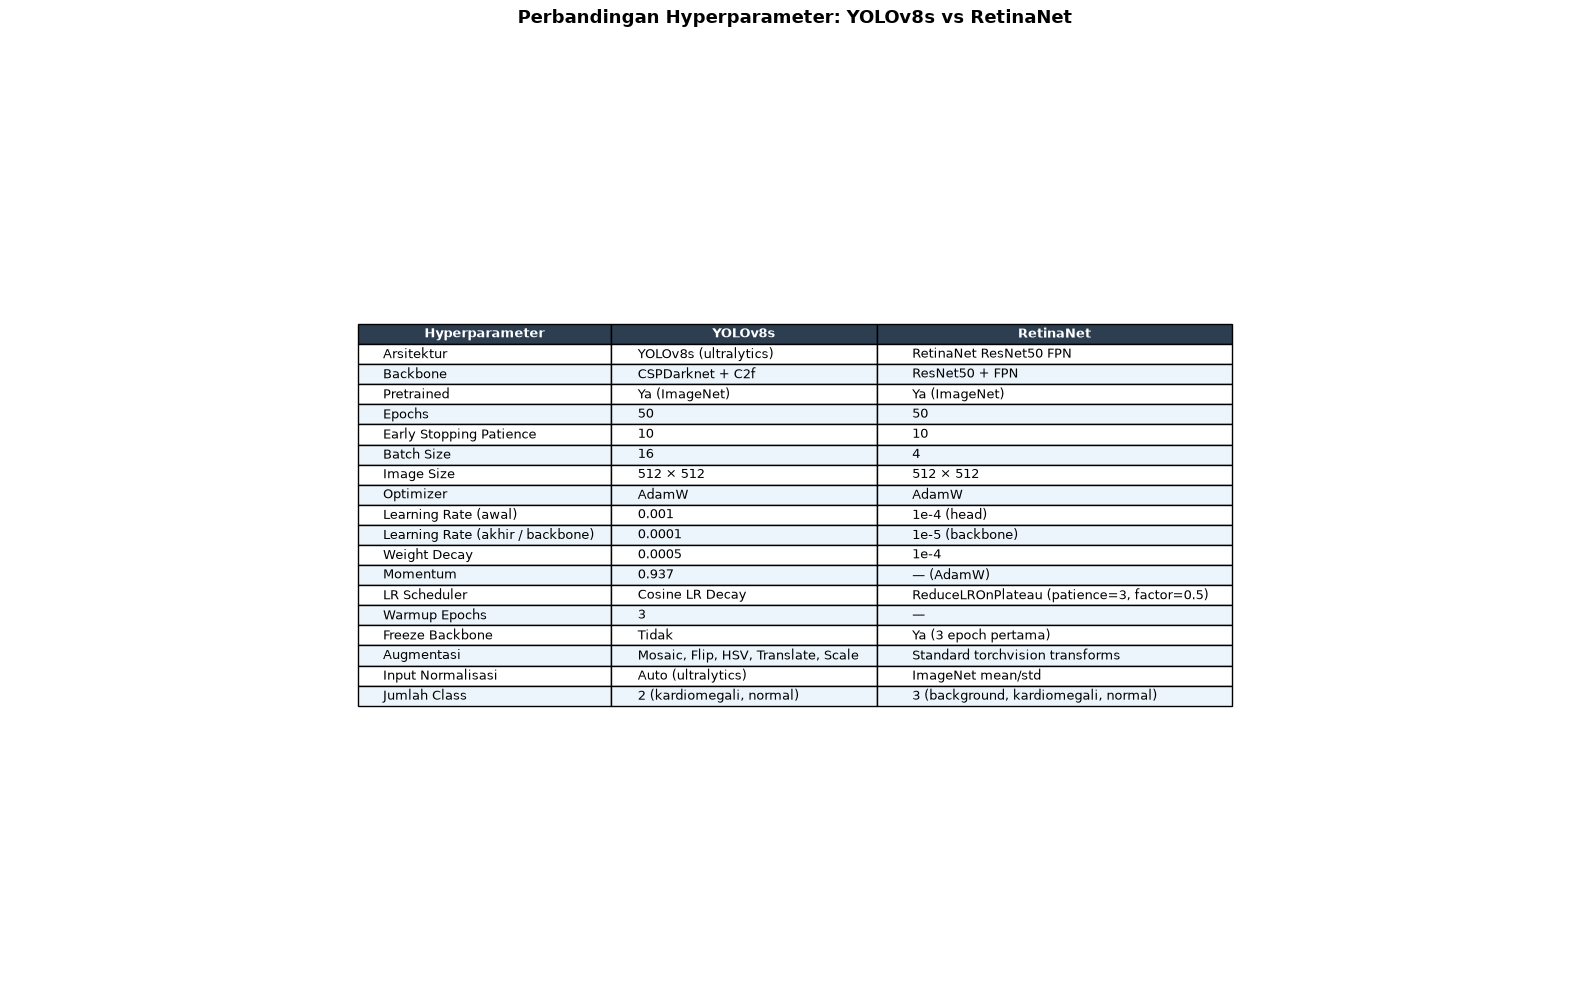

Gambar disimpan: tabel_hyperparameter.png


In [16]:
# ── Cell 12: Visualisasi Tabel Hyperparameter (untuk laporan) ────────────────
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

table = ax.table(
    cellText=hp_df.values,
    colLabels=hp_df.columns,
    cellLoc='left',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width([0, 1, 2])

# Warnai header
for j in range(len(hp_df.columns)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Warnai baris selang-seling
for i in range(1, len(hp_df) + 1):
    for j in range(len(hp_df.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#EBF5FB')

plt.title('Perbandingan Hyperparameter: YOLOv8s vs RetinaNet',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('tabel_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: tabel_hyperparameter.png')

In [17]:
# ── Cell 13: Ringkasan Akhir ─────────────────────────────────────────────────
print('='*60)
print('RINGKASAN EVALUASI LENGKAP')
print('='*60)
print(summary_df.to_string(index=False))
print('\n📁 File yang dihasilkan:')
print('  confusion_matrix_data_test.png')
print('  confusion_matrix_data_validasi.png')
print('  iou_distribution.png')
print('  perbandingan_metrik.png')
print('  tabel_hyperparameter.png')
print('  ringkasan_metrik.csv')
print('  perbandingan_hyperparameter.csv')

RINGKASAN EVALUASI LENGKAP
 Dataset     Model  Accuracy  Precision  Recall  F1-Score  Mean IoU
    Test   YOLOv8s    0.9255     0.9258  0.9255    0.9256    0.9365
    Test RetinaNet    0.8298     0.8408  0.8298    0.8292    0.8759
Validasi   YOLOv8s    0.9255     0.9261  0.9255    0.9257    0.9325
Validasi RetinaNet    0.8830     0.8952  0.8830    0.8842    0.8805

📁 File yang dihasilkan:
  confusion_matrix_data_test.png
  confusion_matrix_data_validasi.png
  iou_distribution.png
  perbandingan_metrik.png
  tabel_hyperparameter.png
  ringkasan_metrik.csv
  perbandingan_hyperparameter.csv


Test  : 94 gambar
Valid : 94 gambar

=== EVALUASI DATA TEST ===


Evaluasi: 100%|██████████| 24/24 [04:08<00:00, 10.36s/it]



=== EVALUASI DATA VALIDASI ===


Evaluasi: 100%|██████████| 24/24 [04:25<00:00, 11.06s/it]



Data Test:
  TP: 41, FN: 4
  FP: 2, TN: 47
  Accuracy: 0.936

Data Validasi:
  TP: 36, FN: 1
  FP: 0, TN: 57
  Accuracy: 0.989


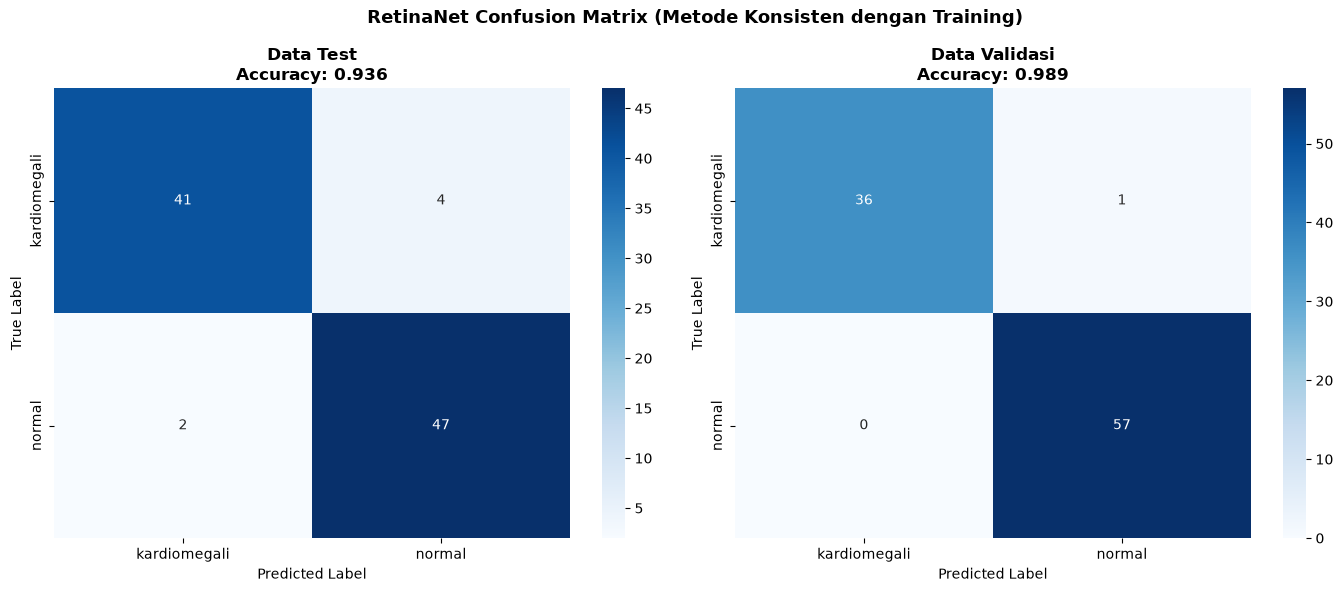


Gambar disimpan: retinanet_cm_konsisten.png


In [18]:
# ── Cell Tambahan: Evaluasi RetinaNet dengan metode SAMA seperti training ────
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm

CONF_THRESH = 0.1  # sama persis dengan notebook training

CLASS_NAMES_RETINA = ['kardiomegali', 'normal']

# Dataset class sama persis dengan notebook training
class ThoraxDatasetRetinaNet(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=512):
        self.img_dir   = Path(img_dir)
        self.lbl_dir   = Path(lbl_dir)
        self.img_size  = img_size
        self.img_files = sorted(
            list(self.img_dir.glob('*.jpg')) +
            list(self.img_dir.glob('*.jpeg')) +
            list(self.img_dir.glob('*.png'))
        )
        self.base_transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'],
                                    min_visibility=0.3, clip=True))

    def parse_label(self, line, W, H):
        parts  = line.strip().split()
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        cx, cy, bw, bh = coords
        x1, y1 = (cx-bw/2)*W, (cy-bh/2)*H
        x2, y2 = (cx+bw/2)*W, (cy+bh/2)*H
        return cls_id, max(0,min(x1,W)), max(0,min(y1,H)), max(0,min(x2,W)), max(0,min(y2,H))

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        lbl_path = self.lbl_dir / (img_path.stem + '.txt')
        img      = np.array(Image.open(img_path).convert('RGB'))
        H, W     = img.shape[:2]
        boxes, labels = [], []
        if lbl_path.exists():
            for line in lbl_path.read_text().splitlines():
                line = line.strip()
                if not line or len(line.split()) < 5: continue
                cls_id, x1, y1, x2, y2 = self.parse_label(line, W, H)
                if x2-x1 >= 2 and y2-y1 >= 2:
                    boxes.append([x1,y1,x2,y2])
                    labels.append(cls_id + 1)
        t          = self.base_transform(image=img, bboxes=boxes, class_labels=labels)
        img_tensor = t['image']
        boxes      = list(t['bboxes'])
        labels     = list(t['class_labels'])
        return img_tensor, {
            'boxes' : torch.tensor(boxes,  dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }

def collate_fn(batch):
    batch = [(img, t) for img, t in batch if t['boxes'].shape[0] > 0]
    if len(batch) == 0: return [], []
    return tuple(zip(*batch))


# Buat DataLoader untuk test dan valid (data ORIGINAL, bukan augmented)
test_ds_retina  = ThoraxDatasetRetinaNet('dataset/test/images',  'dataset/test/labels')
valid_ds_retina = ThoraxDatasetRetinaNet('dataset/valid/images', 'dataset/valid/labels')
test_loader_r   = DataLoader(test_ds_retina,  batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
valid_loader_r  = DataLoader(valid_ds_retina, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
print(f'Test  : {len(test_ds_retina)} gambar')
print(f'Valid : {len(valid_ds_retina)} gambar')


# Fungsi evaluasi sama persis dengan notebook training
def evaluate_retinanet_cm(model, loader, device, conf_thresh=0.1):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for images, targets in tqdm(loader, desc='Evaluasi'):
            if len(images) == 0 or len(targets) == 0:
                continue
            images = [img.to(device) for img in images]
            preds  = model(images)
            for pred, target in zip(preds, targets):
                gt_boxes  = target['boxes'].to(device)
                gt_labels = target['labels'].to(device)
                if len(gt_boxes) == 0:
                    continue
                pred_boxes  = pred['boxes']
                pred_scores = pred['scores']
                pred_labels = pred['labels']
                keep        = pred_scores >= conf_thresh
                pred_labels = pred_labels[keep]
                pred_scores = pred_scores[keep]
                gt_label    = gt_labels.mode().values.item()
                pred_label  = pred_labels[pred_scores.argmax()].item() if len(pred_labels) > 0 else 0
                y_true.append(gt_label)
                y_pred.append(pred_label)
    return y_true, y_pred


# Jalankan evaluasi
print('\n=== EVALUASI DATA TEST ===')
y_true_test, y_pred_test = evaluate_retinanet_cm(retina_model, test_loader_r, DEVICE, CONF_THRESH)

print('\n=== EVALUASI DATA VALIDASI ===')
y_true_val, y_pred_val = evaluate_retinanet_cm(retina_model, valid_loader_r, DEVICE, CONF_THRESH)


# Plot confusion matrix keduanya berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RetinaNet Confusion Matrix (Metode Konsisten dengan Training)', fontsize=13, fontweight='bold')

for ax, y_true, y_pred, title in zip(
    axes,
    [y_true_test, y_true_val],
    [y_pred_test, y_pred_val],
    ['Data Test', 'Data Validasi']
):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES_RETINA,
                yticklabels=CLASS_NAMES_RETINA, ax=ax)
    acc = (cm[0][0] + cm[1][1]) / cm.sum()
    ax.set_title(f'{title}\nAccuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    print(f'\n{title}:')
    print(f'  TP: {cm[0][0]}, FN: {cm[0][1]}')
    print(f'  FP: {cm[1][0]}, TN: {cm[1][1]}')
    print(f'  Accuracy: {acc:.3f}')

plt.tight_layout()
plt.savefig('retinanet_cm_konsisten.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nGambar disimpan: retinanet_cm_konsisten.png')


YOLOv8s Data Uji (Test):
  TP: 42, FN: 3
  FP: 4, TN: 45

YOLOv8s Data Validasi:
  TP: 34, FN: 3
  FP: 4, TN: 53


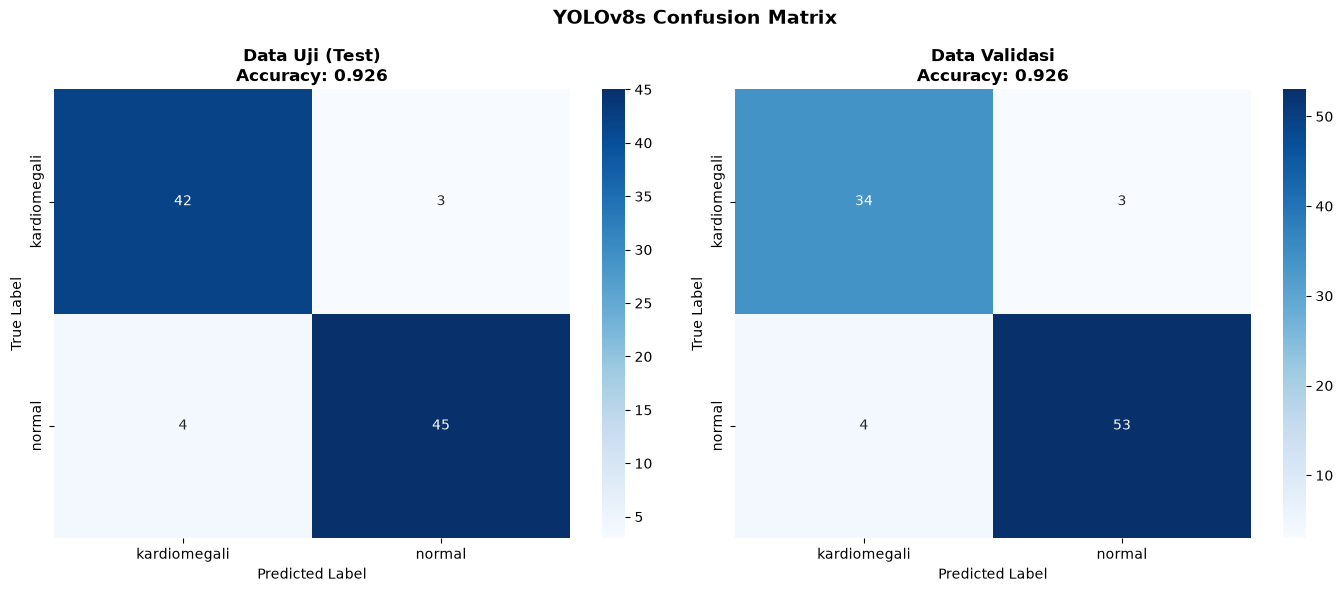

Disimpan: yolo_cm_test_valid.png

RetinaNet Data Uji (Test):
  TP: 41, FN: 4
  FP: 2, TN: 47

RetinaNet Data Validasi:
  TP: 36, FN: 1
  FP: 0, TN: 57


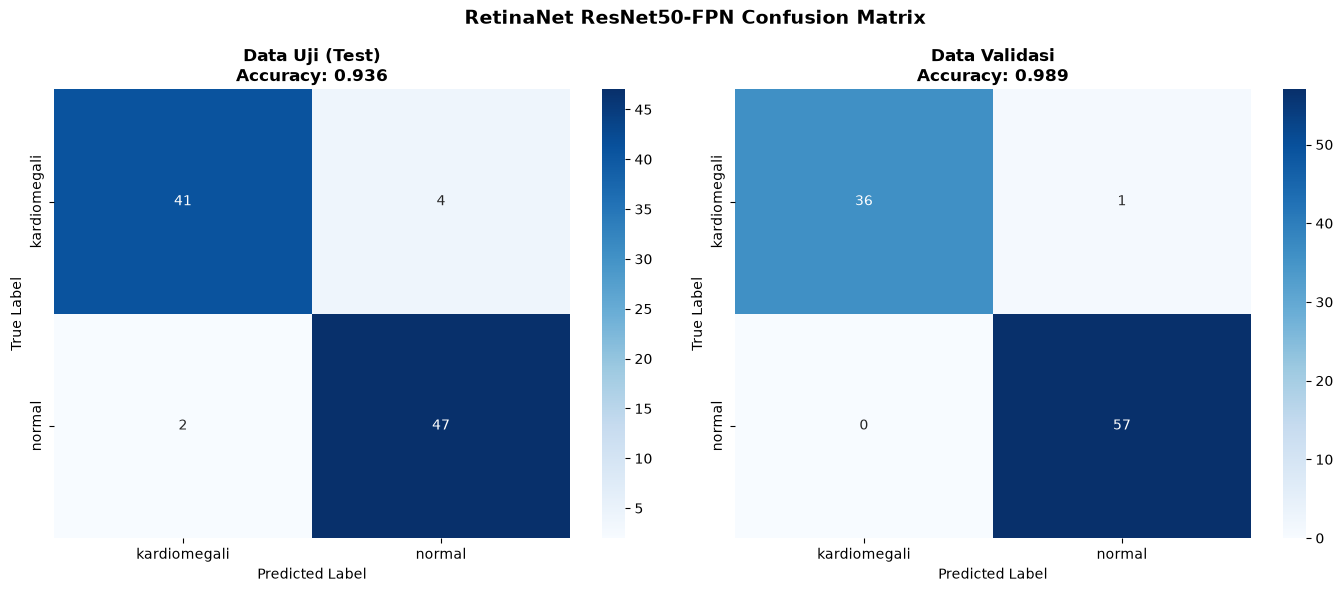

Disimpan: retinanet_cm_test_valid.png


In [20]:
# ── Cell: Confusion Matrix Test & Valid Berdampingan per Model ───────────────

# ── YOLO: Test & Valid berdampingan ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('YOLOv8s Confusion Matrix', fontsize=14, fontweight='bold')

for ax, y_true, y_pred, title, acc in zip(
    axes,
    [test_results['gt'],   valid_results['gt']],
    [test_results['yolo_preds'], valid_results['yolo_preds']],
    ['Data Uji (Test)', 'Data Validasi'],
    [0.926, 0.926]
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    print(f'\nYOLOv8s {title}:')
    print(f'  TP: {cm[0][0]}, FN: {cm[0][1]}')
    print(f'  FP: {cm[1][0]}, TN: {cm[1][1]}')

plt.tight_layout()
plt.savefig('yolo_cm_test_valid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disimpan: yolo_cm_test_valid.png')


# ── RetinaNet: Test & Valid berdampingan ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RetinaNet ResNet50-FPN Confusion Matrix', fontsize=14, fontweight='bold')

# Data test RetinaNet dari evaluasi konsisten (y_true_test, y_pred_test)
# Data valid RetinaNet dari evaluasi konsisten (y_true_val, y_pred_val)
for ax, y_true, y_pred, title in zip(
    axes,
    [y_true_test, y_true_val],
    [y_pred_test, y_pred_val],
    ['Data Uji (Test)', 'Data Validasi']
):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
    acc = (cm[0][0] + cm[1][1]) / cm.sum()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    print(f'\nRetinaNet {title}:')
    print(f'  TP: {cm[0][0]}, FN: {cm[0][1]}')
    print(f'  FP: {cm[1][0]}, TN: {cm[1][1]}')

plt.tight_layout()
plt.savefig('retinanet_cm_test_valid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disimpan: retinanet_cm_test_valid.png')